# Assignment 3: Milestone I Natural Language Processing
## Task 1. Basic Text Pre-processing
#### Student Name:


1.   Vo Ngoc Dung - S4124370
2.   Tang Hoang Ha - S4147768
3.   Nguyen Anh Duc - S4136756
4.   Nguyen Quoc Trong Nghia - S3343711



Environment: Python 3 and Jupyter notebook

Libraries used:
* pandas - for data manipulation
* re - for regular expression tokenization
* numpy - for numerical operations
* collections.Counter - for frequency counting

## Introduction

This task focuses on preprocessing cosmetics and beauty product reviews to prepare them for machine learning classification. The goal is to clean and standardize the text data by:

1. Tokenizing reviews using a specific regex pattern
2. Normalizing text to lowercase
3. Filtering out short words, stopwords, and rare/common terms
4. Building a clean vocabulary for feature extraction

The output will be used in subsequent tasks for building classification models to predict purchase behavior.

## Importing libraries

In [1]:
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import re
import numpy as np
from collections import Counter
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 0. Exploratory Data Analysis (EDA)

## Purpose and Justification

Before performing text preprocessing, we conduct an Exploratory Data Analysis (EDA) to understand the structure and relationships within the dataset. This step is essential for the following reasons:

1. **Informing feature selection for Task 3 (Q2):** Task 3 Scenario 3 requires combining text features with structured features (brand, price, rating, product). By analysing correlations now, we can identify which structured features carry predictive signal and which may be redundant.

2. **Understanding the target variable:** Examining `is_a_buyer` distribution reveals class imbalance, which will influence model evaluation strategy in Task 3.

3. **Identifying potential issues:** Detecting multicollinearity between features early prevents us from including redundant predictors that could degrade model performance.

**Methodology:**
- We use **Pearson correlation** to quantify linear relationships between numeric features and the binary target (`is_a_buyer`).
- Categorical features (`brand_name`, `product_title`) are converted to numeric via `LabelEncoder` to enable correlation computation. Note: LabelEncoder assigns arbitrary ordinal integers alphabetically; this is acceptable for a broad correlation overview but would not be suitable for direct model input (where one-hot encoding is preferred).
- Missing values are imputed with column medians to avoid `NaN` propagation in the correlation matrix.

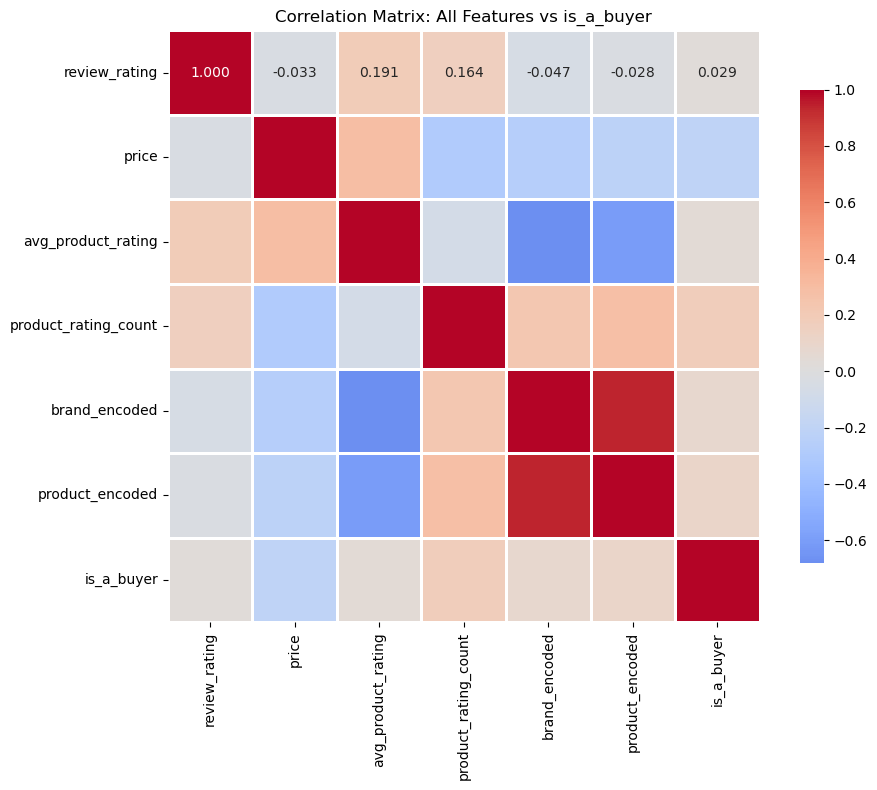

Correlation with is_a_buyer (sorted by strength):
product_rating_count    0.173790
product_encoded         0.101473
brand_encoded           0.085871
avg_product_rating      0.043627
review_rating           0.029100
price                  -0.205573
Name: is_a_buyer, dtype: float64


In [3]:
# Load processed data for EDA
df_eda = pd.read_csv("cosmetics_beauty_products_reviews.csv")

# Encode categorical columns to numeric for correlation analysis
# LabelEncoder converts text categories to integers (e.g., Olay=0, L'Oreal=1)
df_corr = df_eda.copy()
df_corr["brand_encoded"] = LabelEncoder().fit_transform(
    df_corr["brand_name"].fillna("unknown")
)
df_corr["product_encoded"] = LabelEncoder().fit_transform(
    df_corr["product_title"].fillna("unknown")
)

# Select all numeric + encoded columns for correlation matrix
# Excludes: text columns (review_text, review_title), IDs, dates, URLs
numeric_cols = [
    "review_rating",  # Rating given by the reviewer (1-5)
    "price",  # Product price
    "avg_product_rating",  # Average rating of the product across all reviews
    "product_rating_count",  # Total number of ratings for the product
    "brand_encoded",  # Brand name (label encoded)
    "product_encoded",  # Product title (label encoded)
    "is_a_buyer",  # Target variable: 1=buyer, 0=non-buyer
]

# Fill missing values with median to avoid NaN in correlation calculation
df_corr[numeric_cols] = df_corr[numeric_cols].fillna(df_corr[numeric_cols].median())

# Compute correlation matrix
corr_matrix = df_corr[numeric_cols].corr()

# Plot heatmap
# - annot=True: show correlation values in each cell
# - cmap='coolwarm': red=positive, blue=negative correlation
# - center=0: white at zero correlation
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8},
    ax=ax,
)
ax.set_title("Correlation Matrix: All Features vs is_a_buyer")
plt.tight_layout()
plt.show()

# Print correlation values with target variable sorted by strength
print("Correlation with is_a_buyer (sorted by strength):")
print(corr_matrix["is_a_buyer"].drop("is_a_buyer").sort_values(ascending=False))

### Findings: Correlation Matrix Analysis

The Pearson correlation heatmap above quantifies the linear relationship between each pair of features. Values range from -1 (perfect negative) to +1 (perfect positive), with 0 indicating no linear association.

#### Correlation with `is_a_buyer` (target variable)

| Feature | r | Strength | Interpretation |
|---------|---:|----------|---------------|
| `price` | -0.206 | Moderate | **Strongest predictor.** Higher-priced products have proportionally fewer verified buyers, suggesting expensive items attract more "browsing" reviewers. |
| `product_rating_count` | +0.174 | Weak-moderate | More popular products (higher review volume) tend to have more actual buyers writing reviews. |
| `product_encoded` | +0.101 | Weak | Certain products attract more real buyers than others. |
| `brand_encoded` | +0.086 | Weak | Brand identity has a minor influence on purchase likelihood. |
| `avg_product_rating` | +0.044 | Very weak | A higher average rating alone does not meaningfully predict buyer status. |
| `review_rating` | +0.029 | Negligible | The star rating a reviewer gives is essentially unrelated to whether they purchased the product. |

**Key insight:** No structured feature exceeds |r| = 0.21, indicating that all numeric/categorical features are only weakly associated with purchase behaviour. This strongly suggests that **text features** (`review_text`, `review_title`) will be the primary source of discriminative signal for classification in Task 3.

#### Notable inter-feature correlations

| Feature pair | r | Implication |
|-------------|---:|------------|
| `brand_encoded` vs `product_encoded` | +0.934 | Near-perfect correlation because each brand sells a distinct set of products. Including both in a model introduces **multicollinearity** (redundant information), which can inflate variance in linear models. For Task 3 Scenario 3, we should consider using only one of these features. |
| `avg_product_rating` vs `brand_encoded` | -0.681 | Brands differ substantially in average quality/rating, meaning brand identity partially encodes product quality information. |
| `avg_product_rating` vs `product_encoded` | -0.609 | Individual products are strongly tied to their average rating (expected, since each product has a fixed `avg_product_rating`). |

#### Limitations of this analysis
- Pearson correlation only captures **linear** relationships; non-linear patterns would be missed.
- `LabelEncoder` imposes an arbitrary numeric ordering on categorical variables, so correlation values for `brand_encoded` and `product_encoded` should be interpreted cautiously as rough approximations rather than precise measures.

### Feature Distribution Analysis by Buyer Status

**Purpose:** While correlation gives a single summary number, distribution plots reveal the *shape* of the relationship — whether differences between buyers and non-buyers are uniform, concentrated in certain ranges, or driven by outliers.

**Approach:**
- **Count plot** for `review_rating` (discrete 1-5 scale) — shows volume differences per star rating.
- **Violin plots** for continuous features (`price`, `avg_product_rating`, `product_rating_count`, `review_rating`) — display full density distributions, with embedded box plots for median/IQR comparison.
- **Bar chart** of buyer rate per brand (top 15 by review volume) — reveals whether specific brands deviate from the overall average buyer proportion.

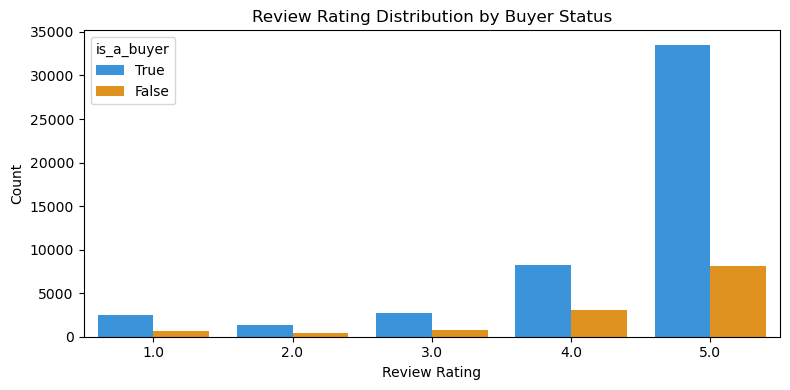

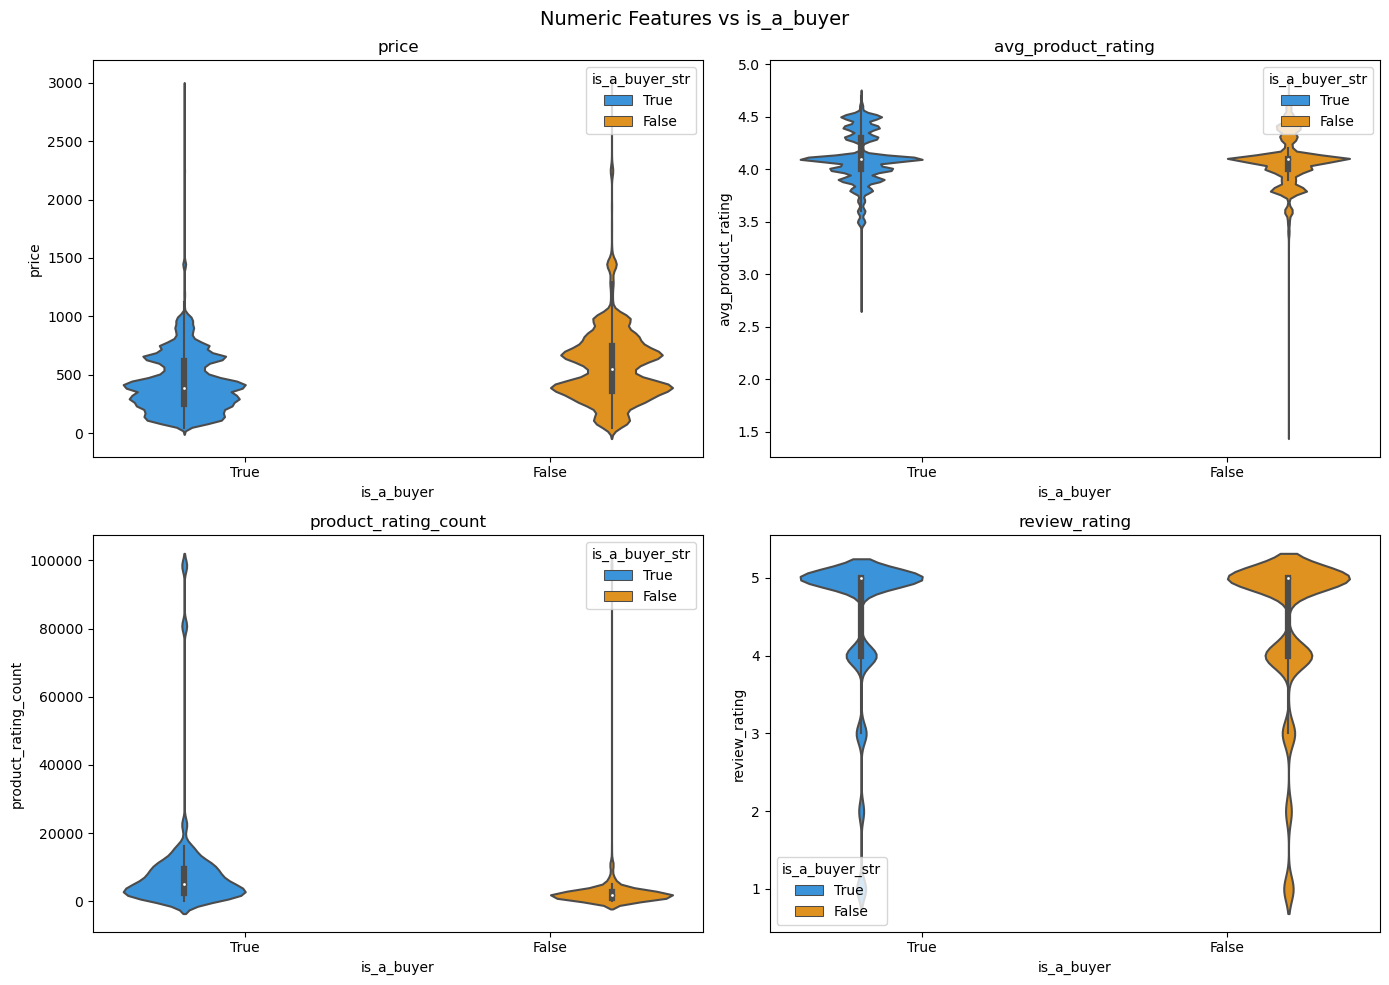

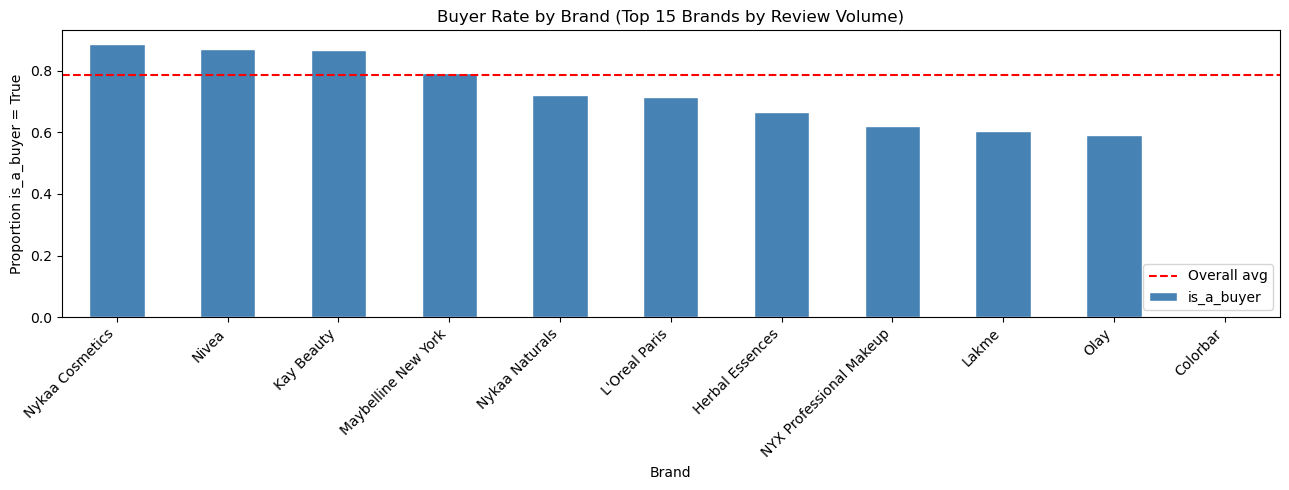

In [4]:
# Convert is_a_buyer to string for seaborn compatibility
df_eda["is_a_buyer_str"] = df_eda["is_a_buyer"].astype(str)

palette = {"True": "#2196F3", "False": "#FF9800"}

# --- 1. Review Rating: count plot (1–5 stars) ---
fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(data=df_eda, x="review_rating", hue="is_a_buyer_str", palette=palette, ax=ax)
ax.set_title("Review Rating Distribution by Buyer Status")
ax.set_xlabel("Review Rating")
ax.set_ylabel("Count")
ax.legend(title="is_a_buyer")
plt.tight_layout()
plt.show()

# --- 2. Numeric columns: violin plots (2×2 grid) ---
numeric_cols = ["price", "avg_product_rating", "product_rating_count", "review_rating"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Numeric Features vs is_a_buyer", fontsize=14)

for ax, col in zip(axes.flat, numeric_cols):
    sns.violinplot(
        data=df_eda, x="is_a_buyer_str", y=col, hue="is_a_buyer_str",
        ax=ax, inner="box", palette=palette, legend=False
    )
    ax.set_title(col)
    ax.set_xlabel("is_a_buyer")

plt.tight_layout()
plt.show()

# --- 3. Brand name: buyer rate for top 15 brands by volume ---
top_brands = df_eda["brand_name"].value_counts().head(15).index
df_brand = df_eda[df_eda["brand_name"].isin(top_brands)]
buyer_rate = (
    df_brand.groupby("brand_name")["is_a_buyer"].mean().sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(13, 5))
buyer_rate.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Buyer Rate by Brand (Top 15 Brands by Review Volume)")
ax.set_ylabel("Proportion is_a_buyer = True")
ax.set_xlabel("Brand")
ax.axhline(
    df_eda["is_a_buyer"].mean(), color="red", linestyle="--", label="Overall avg"
)
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Findings: Feature Distribution Analysis

#### 1. Review Rating (Count Plot)

- Both buyers and non-buyers are heavily skewed toward **5-star ratings**, which is typical of e-commerce review data (satisfied customers are more motivated to review).
- The distribution shape is nearly identical between the two groups, confirming the negligible correlation (r = 0.029) found earlier. **Review rating alone cannot distinguish buyers from non-buyers.**

#### 2. Violin Plots (Continuous Features)

- **Price:** Buyers are concentrated at **lower price ranges**, with a noticeably thinner tail at higher prices compared to non-buyers. This visually confirms the negative correlation (r = −0.206) and suggests that expensive products disproportionately attract non-purchasing reviewers (possibly browsing or aspirational reviews).
- **Product Rating Count:** Buyers tend to cluster around products with **higher rating counts** (more popular items), while non-buyers spread more evenly across low- and high-popularity products. This aligns with the positive correlation (r = +0.174).
- **Average Product Rating:** The distributions for buyers and non-buyers are nearly overlapping, confirming that average product quality is not a meaningful differentiator (r = 0.044).
- **Review Rating:** As expected from the count plot, violin shapes are almost identical between groups.

#### 3. Buyer Rate by Brand (Top 15)

- There is **considerable variation** in buyer rate across brands — some brands exceed 85% buyer proportion while others fall below 70%.
- This suggests that brand identity does carry some predictive information, even though the overall correlation was weak (r = 0.086). The weak correlation is partly due to LabelEncoder's arbitrary ordering, which obscures the true categorical differences.
- Brands with lower prices (e.g., drugstore brands) tend to have higher buyer rates, consistent with the price–buyer relationship observed above.

#### Summary of Distribution Insights

| Feature | Discriminative Power | Key Observation |
|---------|---------------------|-----------------|
| `price` | Moderate | Clear separation — buyers skew toward lower prices |
| `product_rating_count` | Weak-moderate | Buyers favour more popular products |
| `brand_name` | Weak but variable | Some brands deviate significantly from the mean |
| `avg_product_rating` | Negligible | Near-identical distributions |
| `review_rating` | Negligible | Near-identical distributions |

These findings reinforce the earlier conclusion: structured features provide only modest separability between buyers and non-buyers, further motivating the use of **text-based features** as the primary input for classification in Task 3.

### Temporal Analysis: Review Activity by Year

**Purpose:** Examining review volume and buyer proportion over time checks for **temporal drift** — whether the relationship between features and the target changes across years. If buyer behaviour shifts significantly over time, a time-aware train/test split may be needed in Task 3.

**Approach:**
- Stacked bar chart: total review count per year, segmented by buyer status.
- Line chart: proportion of buyers vs non-buyers per year, with annotations for exact percentages.

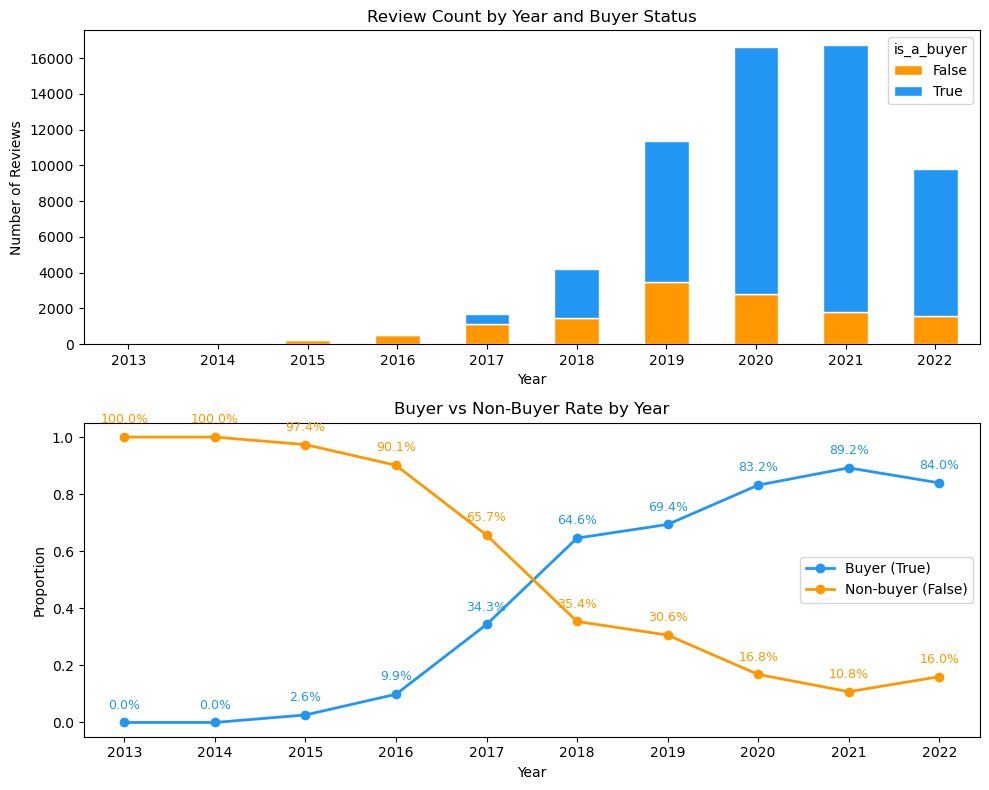

In [5]:
df_eda["year"] = pd.to_datetime(df_eda["review_date"], dayfirst=True).dt.year

yearly = df_eda.groupby(["year", "is_a_buyer_str"]).size().unstack(fill_value=0)
yearly_rate = df_eda.groupby("year")["is_a_buyer"].mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Stacked bar: review count per year by buyer status
yearly.plot(
    kind="bar",
    stacked=True,
    ax=ax1,
    color=[palette["False"], palette["True"]],
    edgecolor="white",
)
ax1.set_title("Review Count by Year and Buyer Status")
ax1.set_xlabel("Year")
ax1.set_ylabel("Number of Reviews")
ax1.legend(title="is_a_buyer", labels=["False", "True"])
ax1.tick_params(axis="x", rotation=0)

# Line: buyer vs non-buyer rate per year
yearly_non_buyer_rate = 1 - yearly_rate

for rate, label, color in [
    (yearly_rate, "Buyer (True)", palette["True"]),
    (yearly_non_buyer_rate, "Non-buyer (False)", palette["False"]),
]:
    ax2.plot(rate.index, rate.values, marker="o", color=color, linewidth=2, label=label)
    for year, val in rate.items():
        ax2.annotate(
            f"{val:.1%}",
            xy=(year, val),
            xytext=(0, 10),
            textcoords="offset points",
            ha="center",
            fontsize=9,
            color=color,
        )

ax2.set_title("Buyer vs Non-Buyer Rate by Year")
ax2.set_xlabel("Year")
ax2.set_ylabel("Proportion")
ax2.legend()
ax2.set_xticks(yearly_rate.index)

plt.tight_layout()
plt.show()

### Findings: Temporal Analysis

#### Review Volume Over Time
- The dataset spans multiple years, with review activity **peaking around 2020–2021** before declining. This likely reflects the growth period of the Nykaa platform and potential impacts of COVID-19 driving increased online shopping and reviewing.
- Buyers consistently outnumber non-buyers across all years, reflecting the overall class imbalance (~79% buyers vs ~21% non-buyers).

#### Buyer Proportion Stability
- The buyer-to-non-buyer ratio remains **relatively stable** across years, fluctuating only within a narrow band. There is no strong upward or downward trend in buyer proportion over time.
- This stability is an important finding: it means **temporal drift is not a major concern** for this dataset. A standard random train/test split (as used in Task 3) is justified — there is no need for a time-based split to avoid data leakage.

#### Implications for Task 3
- Since buyer behaviour does not shift significantly over time, models trained on a random sample should generalise well to other time periods within this dataset.
- The year feature itself is unlikely to be a strong predictor of `is_a_buyer`, given the stable proportions observed.

### 1.1. Examining and Loading Data

**Purpose:** Before any preprocessing, we must understand the dataset's structure — its dimensions, column types, missing values, and target distribution. This informs every downstream decision (e.g., how to handle nulls, which column contains the text to process).

**Observations:**
- The dataset contains **61,284 reviews** across 15 columns, including text fields (`review_text`, `review_title`), numeric features (`price`, `review_rating`), and metadata (`author`, `review_date`, `product_url`).
- **Missing values:** `review_text` has 8 missing entries (negligible — 0.01%), `review_rating` has 1, and `product_tags` has 47,782 (78%). The 8 missing `review_text` values will be replaced with empty strings during tokenization to avoid errors.
- **Target variable (`is_a_buyer`):** After filtering reviews to those from 2017 onwards (removing 877 rows with invalid or pre-2017 dates), the working dataset contains **60,407 reviews** with 48,160 True vs 12,247 False — a **~3.9:1 class imbalance**. This is important context for Task 3, where evaluation metrics like F1-score or balanced accuracy may be more appropriate than raw accuracy.

In [6]:
# Load the dataset
df = pd.read_csv("cosmetics_beauty_products_reviews.csv")

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (61284, 15)

Column names: ['product_id', 'brand_name', 'review_id', 'review_title', 'review_text', 'author', 'review_date', 'review_rating', 'is_a_buyer', 'product_title', 'price', 'avg_product_rating', 'product_rating_count', 'product_tags', 'product_url']

First few rows:


,product_id,brand_name,review_id,review_title,review_text,author,review_date,review_rating,is_a_buyer,product_title,price,avg_product_rating,product_rating_count,product_tags,product_url
0,781070,Olay,16752142,Worth buying 50g one,Works as it claims. Could see the difference f...,Ashton Dsouza,23/01/2021 15:17,5.0,True,Olay Ultra Lightweight Moisturiser: Luminous W...,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...
1,781070,Olay,14682550,Best cream to start ur day,It does what it claims . Best thing is it smoo...,Amrit Neelam,07/09/2020 15:30,5.0,True,Olay Ultra Lightweight Moisturiser: Luminous W...,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...
2,781070,Olay,15618995,perfect for summers dry for winters,I have been using this product for months now....,Sanchi Gupta,13/11/2020 12:24,4.0,True,Olay Ultra Lightweight Moisturiser: Luminous W...,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...
3,781070,Olay,13474509,Not a moisturizer,"i have an oily skin, while this whip acts as a...",Ruchi Shah,14/06/2020 11:56,3.0,True,Olay Ultra Lightweight Moisturiser: Luminous W...,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...
4,781070,Olay,16338982,Average,It's not that good. Please refresh try for oth...,Sukanya Sarkar,22/12/2020 15:24,2.0,True,Olay Ultra Lightweight Moisturiser: Luminous W...,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...


In [7]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Display data types
print("\nData types:")
print(df.dtypes)

Missing values per column:
product_id                  0
brand_name                  0
review_id                   0
review_title                0
review_text                 8
author                      0
review_date                 0
review_rating               1
is_a_buyer                  0
product_title               0
price                       0
avg_product_rating          0
product_rating_count        0
product_tags            47782
product_url                 0
dtype: int64

Data types:
product_id                int64
brand_name               object
review_id                 int64
review_title             object
review_text              object
author                   object
review_date              object
review_rating           float64
is_a_buyer                 bool
product_title            object
price                     int64
avg_product_rating      float64
product_rating_count      int64
product_tags             object
product_url              object
dtype: object


In [8]:
# Keep rows where review_date >= 2017
df["review_date"] = pd.to_datetime(df["review_date"], errors="coerce")
before = len(df)
df = df[df["review_date"].dt.year >= 2017]
print(f"Rows dropped (review_date < 2017 or invalid date): {before - len(df)}")
print(f"Remaining rows (review_date >= 2017): {len(df)}")

# Check the distribution of the target variable
print("\nDistribution of is_a_buyer:")
print(df["is_a_buyer"].value_counts())

# Sample reviews
print("\nSample review text:")
print(df["review_text"].iloc[0])

Rows dropped (review_date < 2017 or invalid date): 877
Remaining rows (review_date >= 2017): 60407

Distribution of is_a_buyer:
True     48160
False    12247
Name: is_a_buyer, dtype: int64

Sample review text:
Works as it claims. Could see the difference from the first day. Use it with Olay cleanser for best results


### 1.2 Loading Stopwords

**Purpose:** Stopwords are high-frequency function words (e.g., "the", "is", "and") that carry grammatical meaning but little semantic content. Removing them reduces noise and vocabulary size without losing information relevant to classifying buyer status.

**Why a custom list instead of NLTK/spaCy defaults?**
- We use the provided `stopwords_en.txt` file (570 words) as specified by the assignment. A custom list ensures consistency and reproducibility across all team members, and avoids dependency on external library versions where default stopword lists may vary.
- The list is loaded into a Python `set` for O(1) lookup performance during filtering — this is more efficient than using a `list`, which would require O(n) lookups per token.

In [9]:
# Load stopwords
with open("stopwords_en.txt", "r", encoding="utf-8") as f:
    stopwords = set(line.strip().lower() for line in f)

print(f"Number of stopwords loaded: {len(stopwords)}")
print(f"Sample stopwords: {list(stopwords)[:20]}")

Number of stopwords loaded: 570
Sample stopwords: ['b', 'seeming', 'way', 'throughout', 'believe', 'thorough', 'amongst', 'knows', 'likely', 'up', 'these', 'specify', 'anywhere', 'sent', 'reasonably', 'cannot', 'tries', 'out', 'you', 'course']


### 1.3 Tokenization Function

**Purpose:** Tokenization splits raw review text into individual word tokens — the fundamental unit for all subsequent NLP processing.

**Why regex-based tokenization instead of alternatives?**

| Alternative | Why not used |
|------------|-------------|
| `str.split()` | Splits only on whitespace — would keep punctuation attached to words (e.g., `"great!"` instead of `"great"`). |
| NLTK `word_tokenize` | Uses Penn Treebank rules — splits contractions differently (e.g., `"don't"` → `["do", "n't"]`), which fragments meaningful units. Also requires downloading extra data (`punkt`). |
| spaCy tokenizer | Heavy dependency for a simple task; also splits contractions and hyphenated words by default. |

**Chosen approach:** Regex pattern `r"[a-zA-Z]+(?:[-'][a-zA-Z]+)?"` because:
1. **Captures only alphabetic tokens** — automatically strips numbers, punctuation, and special characters without a separate cleaning step.
2. **Preserves hyphenated words** (e.g., "anti-aging", "long-lasting") — important in cosmetics reviews where compound descriptors carry meaning.
3. **Preserves contractions** (e.g., "don't", "it's") as single tokens — keeps negations intact, which is valuable for sentiment-related classification.
4. **Lightweight** — no external library dependency; uses Python's built-in `re` module.

In [10]:
def tokenize_text(text):
    """
    Tokenize text using the specified regex pattern.

    Args:
        text: Input text string

    Returns:
        List of tokens
    """
    if pd.isna(text):
        return []

    # Define the regex pattern for tokenization:
    # 1. [a-zA-Z]+ matches the initial sequence of letters.
    # 2. (?:[-'][a-zA-Z]+)? is an optional non-capturing group that allows for
    #    a single hyphen or apostrophe followed by more letters.
    # This ensures words like "long-lasting" or "it's" are treated as single tokens.
    pattern = r"[a-zA-Z]+(?:[-'][a-zA-Z]+)?"
    tokens = re.findall(pattern, text)

    return tokens


# Test the tokenization function
test_text = "This anti-aging cream is great! I don't think it's expensive."
test_tokens = tokenize_text(test_text)
print(f"Test text: {test_text}")
print(f"Tokens: {test_tokens}")

Test text: This anti-aging cream is great! I don't think it's expensive.
Tokens: ['This', 'anti-aging', 'cream', 'is', 'great', 'I', "don't", 'think', "it's", 'expensive']


### 1.4 Initial Tokenization and Lowercase Conversion

**Purpose:** Apply the tokenization function to all 60,407 reviews and normalise tokens to lowercase.

**Why lowercase conversion?**
- Without lowercasing, "Good", "good", and "GOOD" would be treated as three separate vocabulary entries despite having the same meaning. This unnecessarily inflates the vocabulary and fragments word counts.
- Lowercasing is a standard first step in text preprocessing and is applied **before** all subsequent filtering steps so that stopword matching (which uses lowercase entries) works correctly.

**Why not preserve case?**
- Case preservation is useful in tasks like Named Entity Recognition (NER) where capitalisation signals proper nouns. For product review classification, word meaning matters more than capitalisation, so the trade-off of losing case information is acceptable.

**Observation:** After tokenization and lowercasing, the corpus contains **1,290,889 total tokens** with an average of **21.37 tokens per review**. The relatively short average review length is typical of e-commerce platforms where reviews tend to be brief.

In [11]:
# Extract review_text column and handle missing values
reviews = df["review_text"].fillna("").tolist()

print(f"Total number of reviews: {len(reviews)}")

# Tokenize and convert to lowercase
tokenized_reviews = []
for review in reviews:
    tokens = tokenize_text(review)
    # Convert to lowercase
    tokens_lower = [token.lower() for token in tokens]
    tokenized_reviews.append(tokens_lower)

# Display statistics
total_tokens = sum(len(tokens) for tokens in tokenized_reviews)
print(f"Total tokens after tokenization: {total_tokens}")
print(f"Average tokens per review: {total_tokens / len(reviews):.2f}")

# Sample tokenized review
print(f"\nSample tokenized review (first 50 tokens):")
print(tokenized_reviews[0][:50])

Total number of reviews: 60407
Total tokens after tokenization: 1290889
Average tokens per review: 21.37

Sample tokenized review (first 50 tokens):
['works', 'as', 'it', 'claims', 'could', 'see', 'the', 'difference', 'from', 'the', 'first', 'day', 'use', 'it', 'with', 'olay', 'cleanser', 'for', 'best', 'results']


### 1.5 Length Filtering

**Purpose:** Remove tokens with fewer than 2 characters (i.e., single-letter tokens).

**Justification:**
- Single-letter tokens like `"a"`, `"i"`, or stray characters from malformed text carry no meaningful semantic content for classification.
- While some single-letter tokens overlap with stopwords (and would be caught in the next step), applying length filtering first is a cheap, deterministic operation that reduces the workload for subsequent, more expensive filtering steps.

**Why threshold = 2 and not higher (e.g., 3)?**
- A threshold of 3 would also remove meaningful two-letter words that are not stopwords (e.g., "ok", "uv", "ph" — relevant in cosmetics context). A minimum length of 2 strikes a balance between removing noise and retaining domain-specific terms.

**Observation:** This step removed **70,160 tokens (5.44%)** — a small but useful reduction. The modest percentage indicates that most single-character tokens in this dataset are already rare, but removing them prevents them from polluting the vocabulary.

In [12]:
# Apply length filtering
# Remove words with length less than 2 characters
# This step excludes "noise" tokens (e.g., 'a', 'i', or typos) from the dataset.
tokenized_reviews_filtered = []
for tokens in tokenized_reviews:
    # Keep only tokens with length >= 2
    # We use a list comprehension to keep only tokens that meet the minimum length requirement.
    # No replacement is made, the short tokens are simply omitted from the final list.
    filtered_tokens = [token for token in tokens if len(token) >= 2]
    tokenized_reviews_filtered.append(filtered_tokens)

# Calculate and display the impact of length filtering
tokens_after_length = sum(len(tokens) for tokens in tokenized_reviews_filtered)
tokens_removed = total_tokens - tokens_after_length

print(f"Tokens after length filtering: {tokens_after_length}")
print(f"Tokens removed (length < 2): {tokens_removed}")
print(f"Percentage removed: {(tokens_removed / total_tokens * 100):.2f}%")

Tokens after length filtering: 1220729
Tokens removed (length < 2): 70160
Percentage removed: 5.44%


### 1.6 Stopword Removal

**Purpose:** Remove common function words that appear frequently but do not help differentiate between buyers and non-buyers.

**Justification:**
- Stopwords (e.g., "the", "is", "for", "with") dominate token frequency in any English corpus. In bag-of-words or count-vector representations (Task 2), these high-frequency words would overshadow less frequent but more informative terms like "moisturising" or "broke-out".
- Removing them shrinks both the token count and the vocabulary size, improving computational efficiency and model focus.

**Why not skip stopword removal and rely on TF-IDF instead?**
- TF-IDF naturally down-weights common terms, so one could argue stopword removal is redundant. However, in this pipeline, we also generate **unweighted** count vectors (Task 2), where stopwords would dominate. Removing them ensures clean features across all representation types.

**Observation:** Stopword removal is the **most impactful step** in the pipeline, eliminating **663,821 tokens (54.38%)**. This is expected — function words typically account for over half of all tokens in English text. The remaining 556,908 tokens are predominantly content words relevant to product descriptions and opinions.

In [13]:
# Apply stopword filtering
tokenized_reviews_no_stop = []
for tokens in tokenized_reviews_filtered:
    # Remove stopwords
    filtered_tokens = [token for token in tokens if token not in stopwords]
    tokenized_reviews_no_stop.append(filtered_tokens)

# Statistics after stopword removal
tokens_after_stopwords = sum(len(tokens) for tokens in tokenized_reviews_no_stop)
stopwords_removed = tokens_after_length - tokens_after_stopwords

print(f"Tokens after stopword removal: {tokens_after_stopwords}")
print(f"Stopwords removed: {stopwords_removed}")
print(f"Percentage removed: {(stopwords_removed / tokens_after_length * 100):.2f}%")

Tokens after stopword removal: 556908
Stopwords removed: 663821
Percentage removed: 54.38%


### 1.7 Term Frequency Filtering

**Purpose:** Remove words that appear only **once** across the entire corpus (hapax legomena).

**Justification:**
- Words occurring only once are typically misspellings, transliterations, or highly specific terms (e.g., a reviewer's name embedded in text). Since they appear in only a single review, a model cannot learn any generalisable pattern from them.
- Removing them cuts the vocabulary nearly in half (15,621 → 7,984 unique words) while removing only 7,637 token instances — a large vocabulary reduction with minimal information loss.

**Why threshold = 1 (remove only singletons) and not higher?**
- A higher threshold (e.g., remove words appearing < 5 times) would aggressively reduce vocabulary but risks eliminating niche cosmetics terminology that may be meaningful in specific product categories (e.g., "retinol", "glycolic"). Using a threshold of 1 is the most conservative choice that targets only clear noise.

**Why term frequency (total count) and not document frequency here?**
- Term frequency counts total occurrences. A word appearing twice — even if both times in the same document — may still carry some signal. Document frequency filtering (next step) will handle the separate concern of words appearing in too many documents.

**Observation:** 7,637 unique words (48.9% of the vocabulary) appeared only once, but they accounted for just **7,637 token instances (1.4% of remaining tokens)**. This confirms they were noise — many unique forms, but each appearing only once.

In [14]:
# Calculate term frequency (total count across all documents)
term_freq = Counter()
for tokens in tokenized_reviews_no_stop:
    term_freq.update(tokens)

print(f"Total unique words before term frequency filtering: {len(term_freq)}")

# Find words that appear only once
words_once = {word for word, count in term_freq.items() if count == 1}
print(f"Words appearing only once: {len(words_once)}")

# Remove words appearing only once
tokenized_reviews_no_rare = []
for tokens in tokenized_reviews_no_stop:
    filtered_tokens = [token for token in tokens if token not in words_once]
    tokenized_reviews_no_rare.append(filtered_tokens)

# Statistics
tokens_after_rare = sum(len(tokens) for tokens in tokenized_reviews_no_rare)
rare_removed = tokens_after_stopwords - tokens_after_rare

print(f"Tokens after removing rare words: {tokens_after_rare}")
print(f"Rare word tokens removed: {rare_removed}")

Total unique words before term frequency filtering: 15621
Words appearing only once: 7637
Tokens after removing rare words: 549271
Rare word tokens removed: 7637


### 1.8 Document Frequency Filtering

**Purpose:** Remove the **top 20 most frequent words** by document frequency (i.e., the number of distinct documents/reviews containing the word).

**Justification:**
- Words appearing in a very high proportion of documents (e.g., "good" in 13,427 out of 60,407 reviews = 22.2%) behave similarly to stopwords — they are so common across both buyer and non-buyer reviews that they provide little discriminative value.
- Unlike stopword lists which are generic, document frequency filtering is **data-driven** — it identifies domain-specific "pseudo-stopwords" that a generic list would miss (e.g., "nykaa", the platform name, appears in 3,126 documents but carries no buyer/non-buyer signal).

**Why top 20 specifically?**
- This is a practical heuristic. Removing too few words leaves uninformative terms in the vocabulary; removing too many risks discarding useful domain terms. The top 20 targets a clear cluster of very high-frequency words while preserving the long tail of meaningful terms.

**Why document frequency instead of term frequency?**
- A word with high term frequency might appear many times in a few documents (e.g., a reviewer repeating "amazing" 10 times) — still potentially useful. A word with high **document** frequency appears across many reviews, making it a poor discriminator regardless of how often it appears per review.

**Observation:** The removed words are a mix of generic positive sentiment terms ("good", "love", "amazing", "great", "perfect", "beautiful", "nice") and domain terms ("skin", "shade", "hair", "colour", "color", "nykaa"). This removed **125,333 tokens (22.8% of remaining)**, substantially reducing feature dimensionality.

In [15]:
# Calculate document frequency
doc_freq = Counter()
for tokens in tokenized_reviews_no_rare:
    # Count each unique word once per document
    unique_tokens = set(tokens)
    doc_freq.update(unique_tokens)

print(f"Total unique words before document frequency filtering: {len(doc_freq)}")

# Get top 20 most frequent words by document frequency
top_20_words = [word for word, count in doc_freq.most_common(20)]
print(f"\nTop 20 words by document frequency:")
for i, (word, count) in enumerate(doc_freq.most_common(20), 1):
    print(f"{i}. {word}: {count} documents")

# Remove top 20 words
top_20_set = set(top_20_words)
tokenized_reviews_final = []
for tokens in tokenized_reviews_no_rare:
    filtered_tokens = [token for token in tokens if token not in top_20_set]
    tokenized_reviews_final.append(filtered_tokens)

# Statistics
tokens_after_top20 = sum(len(tokens) for tokens in tokenized_reviews_final)
top20_removed = tokens_after_rare - tokens_after_top20

print(f"\nTokens after removing top 20 words: {tokens_after_top20}")
print(f"Top-20 word tokens removed: {top20_removed}")

Total unique words before document frequency filtering: 7984

Top 20 words by document frequency:
1. good: 13427 documents
2. product: 11560 documents
3. love: 8178 documents
4. skin: 8158 documents
5. shade: 7816 documents
6. nice: 5688 documents
7. hair: 5600 documents
8. amazing: 4677 documents
9. perfect: 4511 documents
10. long: 4488 documents
11. colour: 4295 documents
12. smooth: 3974 documents
13. color: 3931 documents
14. great: 3597 documents
15. loved: 3549 documents
16. beautiful: 3544 documents
17. easy: 3441 documents
18. buy: 3183 documents
19. nykaa: 3126 documents
20. time: 3089 documents

Tokens after removing top 20 words: 423938
Top-20 word tokens removed: 125333


### 1.9 Stemming and Lemmatization

**Purpose:** Reduce words to their base/root forms so that morphological variants (e.g., "moisturising", "moisturised", "moisturiser") map to the same token, consolidating their counts and reducing vocabulary size.

**Why combine both lemmatization and stemming?**
- **Lemmatization** (WordNet `WordNetLemmatizer`) uses a vocabulary lookup to map words to their dictionary form (e.g., "mice" → "mouse", "better" → "good"). It is more accurate but only handles known inflectional forms.
- **Stemming** (Porter `PorterStemmer`) applies rule-based suffix stripping (e.g., "moisturising" → "moisturis"). It is more aggressive and catches variants that lemmatization misses, but can produce non-dictionary forms.
- Applying **lemmatization first, then stemming** gives us the best of both: lemmatization handles regular inflections accurately, and stemming catches remaining variants that lemmatization alone would miss.

**Why not use only one?**

| Approach | Limitation |
|----------|-----------|
| Lemmatization only | Misses derivational variants (e.g., "difference" and "different" would remain separate). |
| Stemming only | Over-stems some words (e.g., "university" → "univers"), but since we don't need human-readable output — just consistent tokens for feature vectors — this is acceptable. |
| Neither | Inflected forms fragment the vocabulary, weakening count-based features (Task 2). |

**Design choice — applying stemming after frequency filtering:**
We intentionally apply stemming/lemmatization *after* document frequency filtering (step 1.8) rather than before. This is a deliberate ordering decision: the top-20 document frequency filter targets specific high-frequency surface forms (e.g., "good", "love", "skin") that we want removed regardless of their morphological variants. Applying stemming first would merge variants before filtering, potentially allowing some high-frequency concepts to escape the filter through less common forms. By filtering first on surface forms and then stemming the survivors, we ensure clean removal of the intended high-frequency words while still consolidating the remaining vocabulary.

**Observation:** The total token count remains **423,938** (unchanged from the previous step — stemming/lemmatization changes token forms, not token count). Sample transformations show meaningful consolidation: "works" → "work", "claims" → "claim", "difference" → "differ", "results" → "result".

In [16]:
import nltk
from nltk.stem import PorterStemmer, WordNetLemmatizer

nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# Lemmatize then stem each token
tokenized_reviews_final = [
    [stemmer.stem(lemmatizer.lemmatize(token)) for token in tokens]
    for tokens in tokenized_reviews_final
]

print(
    f"Tokens after stemming & lemmatization: {sum(len(t) for t in tokenized_reviews_final)}"
)

# Show a few examples
sample_before = tokenized_reviews_no_rare[0][:8]  # pre-stem tokens for comparison
sample_after = tokenized_reviews_final[0][:8]
print("\nSample transformations (original → processed):")
for orig, proc in zip(sample_before, sample_after):
    print(f"  {orig:20s} → {proc}")

Tokens after stemming & lemmatization: 423938

Sample transformations (original → processed):
  works                → work
  claims               → claim
  difference           → differ
  day                  → day
  olay                 → olay
  cleanser             → cleanser
  results              → result


### 1.10 Building Final Vocabulary

**Purpose:** Construct the definitive word-to-index mapping that will be used in Task 2 to convert text into numeric feature vectors (count vectors, weighted/unweighted embeddings).

**Requirements:**
- **Alphabetically sorted** — ensures a deterministic, reproducible ordering across runs.
- **Zero-indexed** — indices start from 0, compatible with standard array/matrix indexing in Python.
- **Format `word:index`** — one entry per line, as specified by the assignment.

**Why alphabetical sorting instead of frequency-based ordering?**
- Frequency-based ordering (most common first) is sometimes used for efficiency in neural models, but alphabetical sorting is simpler, deterministic, and makes the vocabulary file human-readable for verification and debugging.

**Observation:** The final vocabulary contains **5,634 unique terms** — reduced from 15,621 before filtering (a 64% reduction). This compact vocabulary retains the most informative words while being small enough for efficient feature extraction in Task 2.

In [17]:
# Collect all unique words from the final processed reviews
vocabulary_set = set()
for tokens in tokenized_reviews_final:
    vocabulary_set.update(tokens)

# Sort alphabetically
vocabulary_list = sorted(vocabulary_set)

print(f"Final vocabulary size: {len(vocabulary_list)}")
print(f"\nFirst 20 words in vocabulary:")
print(vocabulary_list[:20])

# Create word to index mapping
word_to_index = {word: idx for idx, word in enumerate(vocabulary_list)}

print(f"\nSample word-index pairs:")
for word in vocabulary_list[:10]:
    print(f"{word}:{word_to_index[word]}")

Final vocabulary size: 5634

First 20 words in vocabulary:
['aa', 'ab', 'aback', 'abd', 'abh', 'abil', 'abit', 'abnorm', 'abroad', 'absent', 'absolut', 'absorb', 'absorpt', 'absoult', 'abt', 'ac', 'acc', 'accentu', 'accept', 'access']

Sample word-index pairs:
aa:0
ab:1
aback:2
abd:3
abh:4
abil:5
abit:6
abnorm:7
abroad:8
absent:9


### 1.11 Summary Statistics

**Purpose:** Present a consolidated view of the entire preprocessing pipeline to quantify the cumulative impact of each filtering step. This serves as both a sanity check (verifying no step removed an unexpected amount of data) and a reference for reporting in the final submission.

**Key takeaways from the pipeline:**
- The preprocessing reduced total tokens from **1,290,889 → 423,938** (67.2% reduction overall).
- **Stopword removal** was the single most impactful step (54.4% of tokens at that stage), followed by **document frequency filtering** (22.8%).
- **Term frequency filtering** removed the least tokens (1.4%) but nearly halved the vocabulary — a high-value, low-cost step.
- The final corpus averages **7.02 tokens per review** (down from 21.37), meaning each review is now represented by a concise set of content-bearing terms ready for feature extraction.

In [18]:
# Create summary table
summary_data = {
    "Step": [
        "Initial tokenization",
        "After length filtering (>= 2)",
        "After stopword removal",
        "After term freq filtering (count > 1)",
        "After doc freq filtering (remove top 20)",
    ],
    "Total Tokens": [
        total_tokens,
        tokens_after_length,
        tokens_after_stopwords,
        tokens_after_rare,
        tokens_after_top20,
    ],
    "Tokens Removed": [
        0,
        tokens_removed,
        stopwords_removed,
        rare_removed,
        top20_removed,
    ],
}

summary_df = pd.DataFrame(summary_data)
summary_df["Percentage Remaining"] = (
    summary_df["Total Tokens"] / total_tokens * 100
).round(2)

print("\n=== PREPROCESSING SUMMARY ===")
print(summary_df.to_string(index=False))

print(f"\nFinal vocabulary size: {len(vocabulary_list)}")
print(f"Total documents processed: {len(tokenized_reviews_final)}")
print(
    f"Average tokens per document: {tokens_after_top20 / len(tokenized_reviews_final):.2f}"
)


=== PREPROCESSING SUMMARY ===
                                    Step  Total Tokens  Tokens Removed  Percentage Remaining
                    Initial tokenization       1290889               0                100.00
           After length filtering (>= 2)       1220729           70160                 94.56
                  After stopword removal        556908          663821                 43.14
   After term freq filtering (count > 1)        549271            7637                 42.55
After doc freq filtering (remove top 20)        423938          125333                 32.84

Final vocabulary size: 5634
Total documents processed: 60407
Average tokens per document: 7.02


## 2. Saving Required Outputs

Save the processed data and vocabulary in the required formats.

### 2.1 Save vocab.txt

Format: `word:index` (one per line, alphabetically sorted, 0-indexed)

In [19]:
# Save vocabulary to vocab.txt
with open("vocab.txt", "w", encoding="utf-8") as f:
    for word, idx in word_to_index.items():
        f.write(f"{word}:{idx}\n")

print("vocab.txt saved successfully!")
print(f"Total words in vocabulary: {len(word_to_index)}")

# Verify the file
with open("vocab.txt", "r", encoding="utf-8") as f:
    first_10_lines = [f.readline().strip() for _ in range(10)]

print("\nFirst 10 lines of vocab.txt:")
for line in first_10_lines:
    print(line)

vocab.txt saved successfully!
Total words in vocabulary: 5634

First 10 lines of vocab.txt:
aa:0
ab:1
aback:2
abd:3
abh:4
abil:5
abit:6
abnorm:7
abroad:8
absent:9


### 2.2 Save processed.csv

Save the processed reviews back to a CSV file with the same structure as the original.

In [20]:
# Reconstruct the processed review text from tokens
processed_review_texts = []
for tokens in tokenized_reviews_final:
    # Join tokens back into a single string
    processed_text = " ".join(tokens)
    processed_review_texts.append(processed_text)

# Create a copy of the original dataframe and update review_text
df_processed = df.copy()
df_processed["review_text"] = processed_review_texts

# Save to CSV
df_processed.to_csv("processed.csv", index=False)

print("processed.csv saved successfully!")
print(f"Shape: {df_processed.shape}")

# Display sample processed reviews
print("\nSample processed reviews:")
print(df_processed[["review_text", "is_a_buyer"]].head())

processed.csv saved successfully!
Shape: (60407, 15)

Sample processed reviews:
                                         review_text  is_a_buyer
0         work claim differ day olay cleanser result        True
1                  claim thing smoothen ur make soft        True
2  month combin oili greasi absorb quickli moistu...        True
3  oili whip act base primer smoothen moisturis f...        True
4                                    refresh product        True


### 2.3 Verification

Verify that all output files are created correctly.

In [21]:
# Check if files exist
required_files = ["vocab.txt", "processed.csv"]

print("Checking output files:")
for filename in required_files:
    exists = os.path.exists(filename)
    # Using simple text labels instead of symbols
    status = "[FOUND]" if exists else "[MISSING]"
    print(f"{status} {filename}")

    if exists:
        size = os.path.getsize(filename)
        print(f"  Size: {size:,} bytes")

# Verify vocab.txt format
print("\nVerifying vocab.txt format:")
with open("vocab.txt", "r", encoding="utf-8") as f:
    lines = f.readlines()
    print(f"Total lines: {len(lines)}")

    # Check first line format
    first_line = lines[0].strip()
    if ":" in first_line:
        word, idx = first_line.split(":")
        print(f"Format Status: Correct (word='{word}', index='{idx}')")
    else:
        print("Format Status: Error in first line")

    # Check if alphabetically sorted
    words = [line.split(":")[0] for line in lines]
    is_sorted = words == sorted(words)
    print(f"Alphabetically sorted: {is_sorted}")

    # Check if 0-indexed
    first_idx = int(lines[0].split(":")[1].strip())
    last_idx = int(lines[-1].split(":")[1].strip())
    print(f"Index range: {first_idx} to {last_idx}")

Checking output files:
[FOUND] vocab.txt
  Size: 64,635 bytes
[FOUND] processed.csv
  Size: 16,649,127 bytes

Verifying vocab.txt format:
Total lines: 5634
Format Status: Correct (word='aa', index='0')
Alphabetically sorted: True
Index range: 0 to 5633


## Summary

### Dataset Overview
- **61,284** cosmetics and beauty product reviews from the Nykaa platform. After filtering to reviews from 2017 onwards, **60,407 reviews** remain with a **~3.9:1 class imbalance** (48,160 buyers vs 12,247 non-buyers).
- 8 missing `review_text` entries (handled as empty strings), 1 missing `review_rating`, and 47,782 missing `product_tags` (not used in this task).

### EDA Findings
- **Correlation analysis** revealed that no structured feature exceeds |r| = 0.21 with `is_a_buyer`. `price` (r = −0.206) and `product_rating_count` (r = +0.174) are the strongest structured predictors, but overall, structured features provide only weak signal — reinforcing the importance of **text-based features** for classification.
- **Distribution analysis** confirmed that buyers skew toward lower-priced and more popular products, while `review_rating` and `avg_product_rating` show near-identical distributions across buyer groups.
- **Temporal analysis** showed stable buyer proportions across years, justifying a standard random train/test split in Task 3 (no temporal drift concern).
- **Multicollinearity:** `brand_encoded` and `product_encoded` are near-perfectly correlated (r = 0.934) — using both in Task 3 Scenario 3 would introduce redundancy.

### Preprocessing Pipeline

| Step | Technique | Justification | Impact |
|------|-----------|---------------|--------|
| 1.3 Tokenization | Regex `r"[a-zA-Z]+(?:[-'][a-zA-Z]+)?"` | Preserves hyphenated words and contractions; strips punctuation/numbers automatically; no external dependency. Preferred over `str.split()` (keeps punctuation) and NLTK `word_tokenize` (fragments contractions). | — |
| 1.4 Lowercase | `token.lower()` | Prevents vocabulary fragmentation ("Good" ≠ "good"). Applied before stopword matching. | 1,290,889 tokens |
| 1.5 Length filter | Remove tokens < 2 chars | Eliminates single-letter noise ("a", "i") while preserving domain terms ("uv", "ph"). | −70,160 (5.44%) |
| 1.6 Stopwords | Custom `stopwords_en.txt` (570 words) | Removes function words that dominate counts but carry no discriminative signal. Custom list ensures reproducibility. | −663,821 (54.38%) |
| 1.7 Term freq filter | Remove count = 1 | Targets misspellings and unique strings (48.9% of vocabulary but only 1.4% of tokens). Conservative threshold preserves niche terms. | −7,637 (1.4%) |
| 1.8 Doc freq filter | Remove top 20 by doc freq | Data-driven removal of domain "pseudo-stopwords" (e.g., "good", "product", "nykaa") that generic lists miss. | −125,333 (22.8%) |
| 1.9 Stemming + Lemmatization | WordNet lemmatizer → Porter stemmer | Combines vocabulary-accurate lemmatization with aggressive suffix stripping. Consolidates morphological variants (e.g., "moisturising"/"moisturised" → "moisturis"). | Vocab reduced, token count unchanged |

**Overall reduction:** 1,290,889 → 423,938 tokens (67.2%), with a final vocabulary of **5,634 unique terms** and an average of **7.02 tokens per review**.

### Output Files
- **`vocab.txt`** — 5,634 entries in `word:index` format, alphabetically sorted, zero-indexed. Verified: correct format, sorted, index range 0–5633.
- **`processed.csv`** — Same 15-column structure as the original dataset, with `review_text` replaced by cleaned/stemmed tokens joined by spaces. Shape: (60,407 × 15).

### Next Steps
The processed data and vocabulary will be used in **Task 2** to generate feature representations (count vectors, weighted/unweighted embeddings), which will then serve as input for machine learning classification models in **Task 3** to predict purchase behaviour (`is_a_buyer`).